# **Workflow Data Mining**

`Menerapkan Naive Bayes terhadap komentar chat live youtube untuk mengetahui apakah komentar tersebut masuk spam normal/promosi judi online`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn untuk Modeling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sastrawi untuk Preprocessing Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# nlp.id untuk lemmatizer Preprocessing teks indo
from nlp_id.lemmatizer import Lemmatizer 

# Untuk menyimpan model
import joblib

/home/qiddis/Documents/Orange/Projek_UAS_UTS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Preview Data:
              datetime           author_name  \
0  2024-10-07 08:32:03                KUSUMA   
1  2024-10-07 08:58:42            Tata PaNda   
2  2024-10-07 09:20:29  Nimas putri Paranata   
3  2024-10-07 09:30:23   proboyuwono djogdja   
4  2024-10-07 09:34:59    Vian Noorcha Putra   

                                             message  \
0                                 assalamu'alaikum..   
1                                  wa'alaikumussalam   
2                             udah lewat 22 menit ni   
3                                          16:30 wib   
4  Tribun Tv Mana Ini Kenapa Acaranya Belum Dimul...   

                                     cleaned_message  label  
0                                    assalamualaikum      0  
1                                   waalaikumussalam      0  
2                             udah lewat 22 menit ni      0  
3                                           1630 wib      0  
4  tribun tv mana ini kenapa acaranya belum dimul.

/tmp/ipykernel_9161/1022822775.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


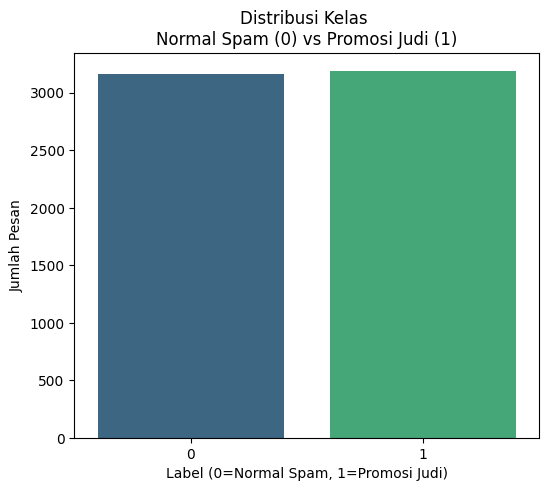

In [2]:
# Load data
df = pd.read_csv('../Datasets/youtube_chat_jogja_clean.csv')

# Tampilkan 5 data pertama
print("Preview Data:")
print(df.head())

# Cek distribusi label (Normal vs Spam)
print("\nDistribusi Label:")
print(df['label'].value_counts())

# Visualisasi Distribusi Label
plt.figure(figsize=(6,5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribusi Kelas \nNormal Spam (0) vs Promosi Judi (1)')
plt.xlabel('Label (0=Normal Spam, 1=Promosi Judi)')
plt.ylabel('Jumlah Pesan')
plt.show()

In [3]:
# Inisialisasi Sastrawi
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()
stemmer = StemmerFactory().create_stemmer()
lemmatizer = Lemmatizer()

def preprocess_text(text):
    # 1. Tokenisasi ==
    tokens = text.split()

    # 2. Lowercase (Case Folding)
    text = text.lower()

    # 3. Hapus Tanda Baca & Angka (Opsional, sesuai kebutuhan)
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])

    # 4. Hapus Stopword
    text = stopword.remove(text)

    # # 5. Stemming (opsional, bisa diaktifkan jika diperlukan)
    # text = stemmer.stem(text)

    # 6. Lemmatization (Opsional, bisa diaktifkan jika diperlukan) ==
    text = lemmatizer.lemmatize(text)

    return text

# Terapkan preprocessing pada kolom 'cleaned_message' 
# (Catatan: Jika 'cleaned_message' sudah sangat bersih, langkah ini bisa di-skip, 
# tapi disarankan tetap dijalankan untuk konsistensi pipeline)
df['text_processed'] = df['message'].fillna('').astype(str).apply(preprocess_text)

# Cek hasil preprocessing
print("\nContoh Hasil Preprocessing:")
print(df[['message', 'text_processed']].head())


Contoh Hasil Preprocessing:
                                             message  \
0                                 assalamu'alaikum..   
1                                  wa'alaikumussalam   
2                             udah lewat 22 menit ni   
3                                          16:30 wib   
4  Tribun Tv Mana Ini Kenapa Acaranya Belum Dimul...   

                                      text_processed  
0                                    assalamualaikum  
1                                   waalaikumussalam  
2                                udah lewat menit ni  
3                                                wib  
4  tribun tv mana kenapa acara mulai wayang jogja...  


In [4]:
X = df['text_processed']  # Fitur (Teks)
y = df['label']           # Target (Label)

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

Jumlah Data Latih: 5080
Jumlah Data Uji: 1270


In [5]:
# Inisialisasi TF-IDF
vectorizer = TfidfVectorizer(max_features=5000) # Ambil 5000 fitur kata terbanyak

# Fit pada data latih, transform ke data latih & uji
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Bentuk Matriks Fitur Latih: {X_train_vec.shape}")

Bentuk Matriks Fitur Latih: (5080, 3266)


In [6]:
# 1. Multinomial Naive Bayes (Utama)
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# # 2. Logistic Regression (Pembanding)
# lr_model = LogisticRegression(max_iter=1000)
# lr_model.fit(X_train_vec, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!



--- Evaluasi Naive Bayes ---
Akurasi: 0.9496
Classification Report:
              precision    recall  f1-score   support

 Normal Spam       1.00      0.90      0.95       633
Promosi Judi       0.91      1.00      0.95       637

    accuracy                           0.95      1270
   macro avg       0.95      0.95      0.95      1270
weighted avg       0.95      0.95      0.95      1270



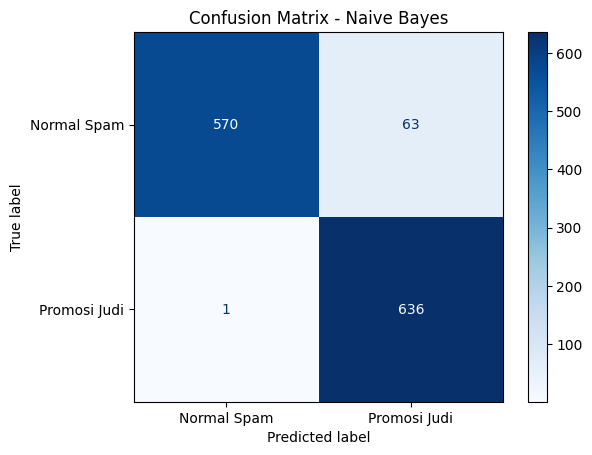

In [8]:
# Fungsi bantu evaluasi
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n--- Evaluasi {name} ---")
    print(f"Akurasi: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal Spam', 'Promosi Judi']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal Spam', 'Promosi Judi'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    return acc

# Evaluasi
acc_nb = evaluate_model(nb_model, "Naive Bayes", X_test_vec, y_test)
# acc_lr = evaluate_model(lr_model, "Logistic Regression", X_test_vec, y_test)

In [ ]:
# Simulasi data baru (Nanti diganti dengan load csv 500 data)
# data_baru = pd.DataFrame({
#     'message': [
#         "info link gacor hari ini",
#         "selamat ulang tahun jogja istimewa",
#         "daftar dapat 100rb wisdomtoto",
#         "kapan mulainya min?"
#     ]
# })
data_baru = pd.read_csv('../Datasets/infer.csv')

# Preprocessing data baru (WAJIB SAMA dengan data latih)
data_baru['text_processed'] = data_baru['message'].apply(preprocess_text)

# Vectorisasi data baru (gunakan vectorizer yang sudah di-fit sebelumnya)
data_baru_vec = vectorizer.transform(data_baru['text_processed'])

# Prediksi
prediksi_nb = nb_model.predict(data_baru_vec)
probabilitas_nb = nb_model.predict_proba(data_baru_vec)

# Tampilkan Hasil
data_baru['Predik_Label'] = prediksi_nb
data_baru['Prob_Judi'] = probabilitas_nb[:, 1] # Probabilitas kelas 1

print("\nHasil Prediksi Data Baru:")
print(data_baru[['message', 'Predik_Label', 'Prob_Judi']])



Hasil Prediksi Data Baru:
                                             message  Predik_Label  Prob_Judi
0          Selamat Pagi pak, izin menyimak materinya             0   0.045603
1  INFO POLA GACOR RTP 99% MAXWIN MALAM INI CUS D...             1   0.596637
2  Bng bahas materi tentang sistem terdistribusi ...             0   0.234659
3    LINK SITUS RESMI ANTI RUNGKAD DEPO 10K PASTI WD             1   0.684923
4          suaranya agak kecil bang coba cek mic nya             0   0.091586
5                    Selamat malam link Gacor Slot88             0   0.389290
6                             Main di BWTOGEL Gacorr             1   0.980084
7                         Main di SLOT88 lebih gacor             1   0.831253
8                                    Assalamualaikum             0   0.179189


# **Ini Untuk Ekspor Model Naive Bayes (Sama format Vector nya)**
`Siapa tau nanti mau dipakai sebagai fitur di sebuah aplikasi`

In [ ]:
# # Simpan model dan vectorizer
# joblib.dump(nb_model, 'model_naive_bayes.pkl')
# joblib.dump(vectorizer, 'vectorizer_tfidf.pkl')

# print("Model dan Vectorizer berhasil disimpan!")